In [15]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder

sns.color_palette("rocket", as_cmap=True)

%matplotlib inline

In [16]:
df = pd.read_csv("CoffeeAndCode.csv")

df

,CodingHours,CoffeeCupsPerDay,CoffeeTime,CodingWithoutCoffee,CoffeeType,CoffeeSolveBugs,Gender,Country,AgeRange
0,8,2,Before coding,Yes,Caffè latte,Sometimes,Female,Lebanon,18 to 29
1,3,2,Before coding,Yes,Americano,Yes,Female,Lebanon,30 to 39
2,5,3,While coding,No,Nescafe,Yes,Female,Lebanon,18 to 29
3,8,2,Before coding,No,Nescafe,Yes,Male,Lebanon,NaN
4,10,3,While coding,Sometimes,Turkish,No,Male,Lebanon,18 to 29
...,...,...,...,...,...,...,...,...,...
95,6,2,Before coding,Yes,Nescafe,Yes,Male,Lebanon,18 to 29
96,4,1,Before coding,Sometimes,Nescafe,Sometimes,Female,Lebanon,18 to 29
97,10,3,Before coding,Yes,Cappuccino,Yes,Male,Lebanon,Under 18
98,2,2,While coding,Sometimes,Espresso (Short Black),Sometimes,Female,Lebanon,18 to 29


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   CodingHours          100 non-null    int64
 1   CoffeeCupsPerDay     100 non-null    int64
 2   CoffeeTime           100 non-null    str  
 3   CodingWithoutCoffee  100 non-null    str  
 4   CoffeeType           99 non-null     str  
 5   CoffeeSolveBugs      100 non-null    str  
 6   Gender               100 non-null    str  
 7   Country              100 non-null    str  
 8   AgeRange             98 non-null     str  
dtypes: int64(2), str(7)
memory usage: 7.2 KB


In [22]:
encoders = {}
df1 = df.copy()
for col in df1.columns: 
    if type(df1[col]) != np.int64:
        encoders[col] = LabelEncoder()
        df1[col] = encoders[col].fit_transform(df1[col])

df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   CodingHours          100 non-null    int64
 1   CoffeeCupsPerDay     100 non-null    int64
 2   CoffeeTime           100 non-null    int64
 3   CodingWithoutCoffee  100 non-null    int64
 4   CoffeeType           100 non-null    int64
 5   CoffeeSolveBugs      100 non-null    int64
 6   Gender               100 non-null    int64
 7   Country              100 non-null    int64
 8   AgeRange             100 non-null    int64
dtypes: int64(9)
memory usage: 7.2 KB


<Axes: >

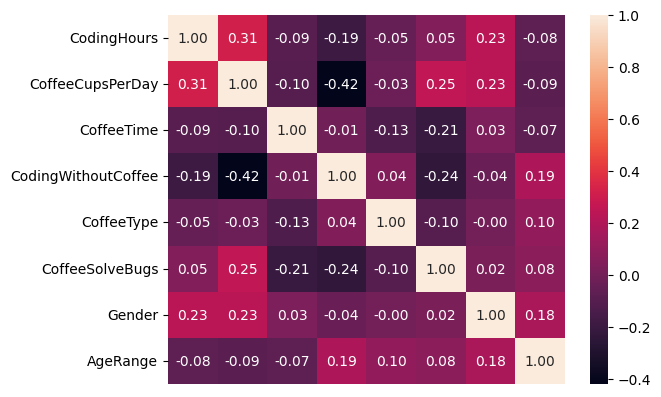

In [25]:
sns.heatmap(df1[[col for col in df1.columns if col != "Country"]].corr(), annot=True, fmt=".2f", xticklabels=False, yticklabels=True)

/tmp/ipykernel_23740/2695472427.py:54: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


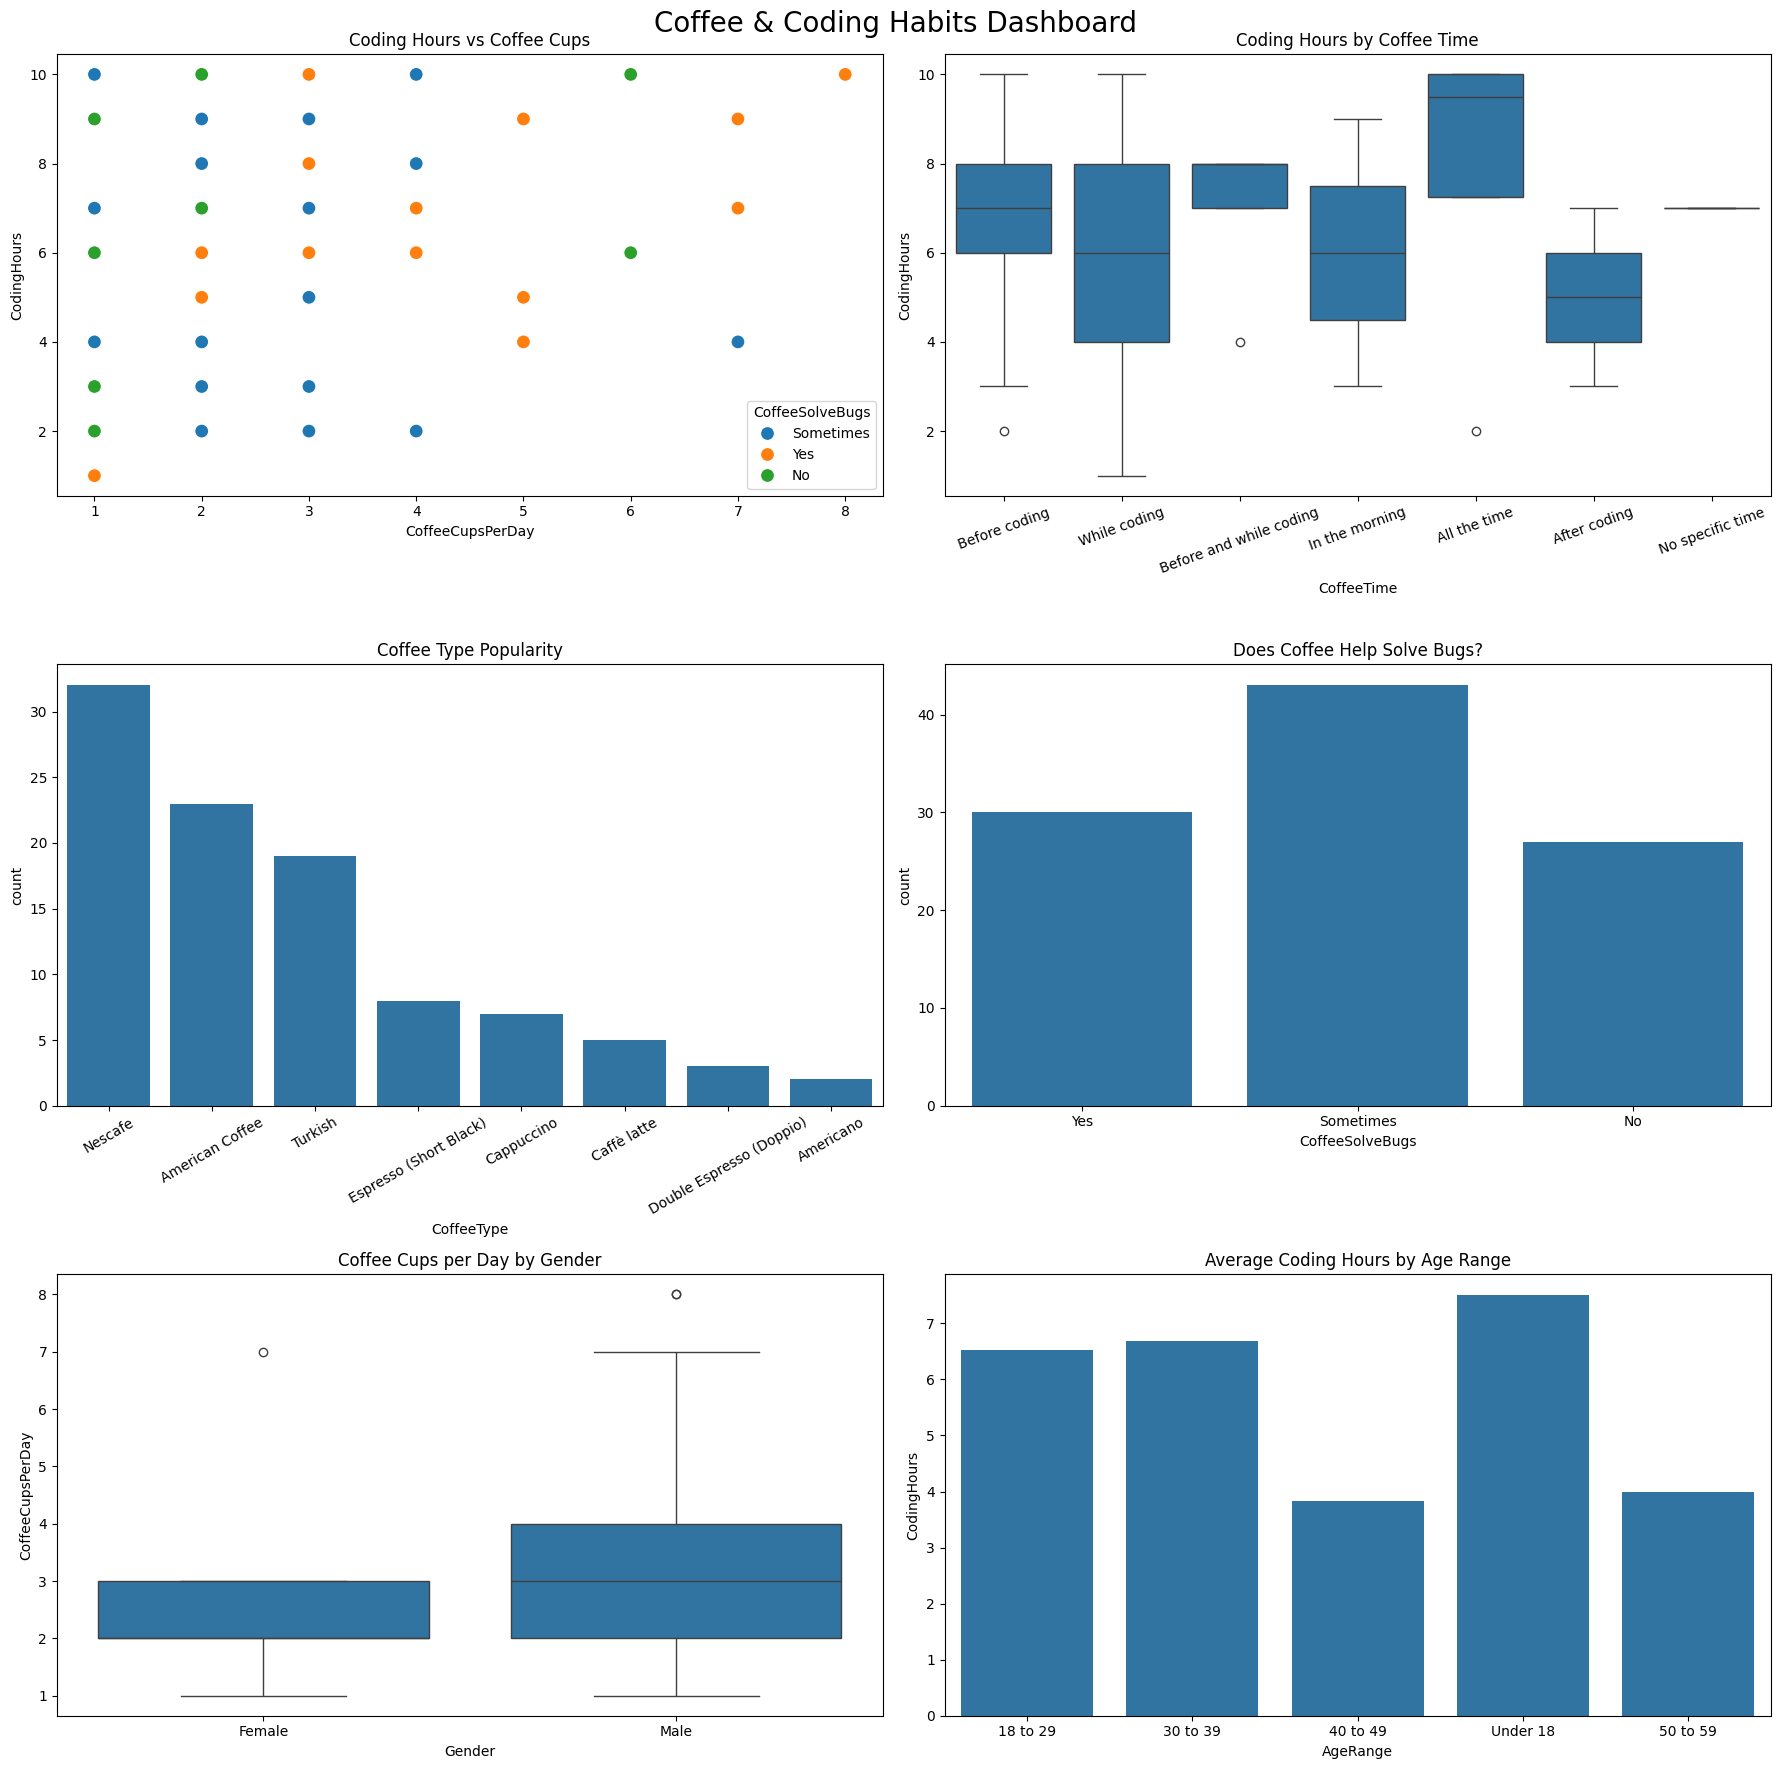

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
fig.suptitle("Coffee & Coding Habits Dashboard", fontsize=20, y=0.98)

sns.scatterplot(
    data=df,
    x="CoffeeCupsPerDay",
    y="CodingHours",
    hue="CoffeeSolveBugs",
    s=100,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Coding Hours vs Coffee Cups")


sns.boxplot(
    data=df,
    x="CoffeeTime",
    y="CodingHours",
    ax=axes[0, 1]
)

axes[0, 1].set_title("Coding Hours by Coffee Time")
axes[0, 1].tick_params(axis="x", rotation=20)

sns.countplot(
    data=df,
    x="CoffeeType",
    order=df["CoffeeType"].value_counts().index,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Coffee Type Popularity")
axes[1, 0].tick_params(axis="x", rotation=30)

sns.countplot(
    data=df,
    x="CoffeeSolveBugs",
    order=["Yes", "Sometimes", "No"],
    ax=axes[1, 1]
)

axes[1, 1].set_title("Does Coffee Help Solve Bugs?")

sns.boxplot(
    data=df,
    x="Gender",
    y="CoffeeCupsPerDay",
    ax=axes[2, 0]
)

axes[2, 0].set_title("Coffee Cups per Day by Gender")

sns.barplot(
    data=df,
    x="AgeRange",
    y="CodingHours",
    estimator="mean",
    ci=None,
    ax=axes[2, 1]
)

axes[2, 1].set_title("Average Coding Hours by Age Range")

plt.tight_layout()
plt.show()